In [ ]:
# Install required libraries
!pip install kagglehub pandas matplotlib seaborn plotly

# Import libraries
import kagglehub
import pandas as pd

# Download Netflix dataset directly from Kaggle
path = kagglehub.dataset_download("shivamb/netflix-shows")

# Print location where dataset is stored
print("Dataset downloaded to:", path)

Using Colab cache for faster access to the 'netflix-shows' dataset.
Dataset downloaded to: /kaggle/input/netflix-shows


In [ ]:
# Import os module to work with file paths
import os

# Display all files present in the downloaded dataset folder
print(os.listdir(path))

['netflix_titles.csv']


In [ ]:
# Read CSV file into a DataFrame
df = pd.read_csv(f"{path}/netflix_titles.csv")

# Display first 5 rows of dataset
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [ ]:
# Display number of rows and columns
print("Dataset Shape:")
print(df.shape)

# Display column names
print("\nColumns:")
print(df.columns)

Dataset Shape:
(8807, 12)

Columns:
Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')


In [ ]:
# Show information about each column
df.info()
# Count missing values in each column
missing_values = df.isnull().sum()

print("Missing Values:")
print(missing_values)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB
Missing Values:
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
descr

In [ ]:
# Generate summary statistics
df.describe(include='all')

# Create separate duration columns
df['movie_duration'] = None
df['tv_seasons'] = None

# For Movies: extract minutes
df.loc[df['type'] == 'Movie', 'movie_duration'] = (
    df.loc[df['type'] == 'Movie', 'duration']
      .str.extract(r'(\d+)', expand=False)
      .astype(float)
)

# For TV Shows: extract seasons
df.loc[df['type'] == 'TV Show', 'tv_seasons'] = (
    df.loc[df['type'] == 'TV Show', 'duration']
      .str.extract(r'(\d+)', expand=False)
      .astype(float)
)

# Check results
df[['type', 'duration', 'movie_duration', 'tv_seasons']].head(10)

,type,duration,movie_duration,tv_seasons
0,Movie,90 min,90.0,None
1,TV Show,2 Seasons,None,2.0
2,TV Show,1 Season,None,1.0
3,TV Show,1 Season,None,1.0
4,TV Show,2 Seasons,None,2.0
5,TV Show,1 Season,None,1.0
6,Movie,91 min,91.0,None
7,Movie,125 min,125.0,None
8,TV Show,9 Seasons,None,9.0
9,Movie,104 min,104.0,None


In [ ]:
# Split multiple countries into separate rows
country_df = (
    df.assign(country=df['country'].str.split(','))
      .explode('country')
)

# Remove leading/trailing spaces
country_df['country'] = country_df['country'].str.strip()

# Preview
country_df[['title', 'country']].head()

,title,country
0,Dick Johnson Is Dead,United States
1,Blood & Water,South Africa
2,Ganglands,NaN
3,Jailbirds New Orleans,NaN
4,Kota Factory,India


In [ ]:
# Split multiple cast members into separate rows
cast_df = (
    df.assign(cast=df['cast'].str.split(','))
      .explode('cast')
)

# Remove leading/trailing spaces
cast_df['cast'] = cast_df['cast'].str.strip()

# Preview
cast_df[['title', 'cast']].head()

,title,cast
0,Dick Johnson Is Dead,NaN
1,Blood & Water,Ama Qamata
1,Blood & Water,Khosi Ngema
1,Blood & Water,Gail Mabalane
1,Blood & Water,Thabang Molaba


In [ ]:
# Split multiple directors into separate rows
director_df = (
    df.assign(director=df['director'].str.split(','))
      .explode('director')
)

# Remove leading/trailing spaces
director_df['director'] = director_df['director'].str.strip()

# Preview
director_df[['title', 'director']].head()

,title,director
0,Dick Johnson Is Dead,Kirsten Johnson
1,Blood & Water,NaN
2,Ganglands,Julien Leclercq
3,Jailbirds New Orleans,NaN
4,Kota Factory,NaN


In [ ]:
# Split multiple genres into separate rows
genre_df = (
    df.assign(listed_in=df['listed_in'].str.split(','))
      .explode('listed_in')
)

# Remove leading/trailing spaces
genre_df['listed_in'] = genre_df['listed_in'].str.strip()

# Preview
genre_df[['title', 'listed_in']].head()

,title,listed_in
0,Dick Johnson Is Dead,Documentaries
1,Blood & Water,International TV Shows
1,Blood & Water,TV Dramas
1,Blood & Water,TV Mysteries
2,Ganglands,Crime TV Shows


In [ ]:
print("Original rows:", len(df))
print("Country rows:", len(country_df))
print("Cast rows:", len(cast_df))
print("Director rows:", len(director_df))
print("Genre rows:", len(genre_df))

Original rows: 8807
Country rows: 10850
Cast rows: 64951
Director rows: 9612
Genre rows: 19323


In [ ]:
# Convert date_added from string to datetime format
df['date_added'] = pd.to_datetime(
    df['date_added'],
    errors='coerce'
)

# Extract year
df['added_year'] = df['date_added'].dt.year

# Extract month name
df['added_month'] = df['date_added'].dt.month_name()

# Extract day of the week
df['added_day'] = df['date_added'].dt.day_name()

# Display sample results
df[['date_added', 'added_year', 'added_month', 'added_day']].head(10)

,date_added,added_year,added_month,added_day
0,2021-09-25,2021.0,September,Saturday
1,2021-09-24,2021.0,September,Friday
2,2021-09-24,2021.0,September,Friday
3,2021-09-24,2021.0,September,Friday
4,2021-09-24,2021.0,September,Friday
5,2021-09-24,2021.0,September,Friday
6,2021-09-24,2021.0,September,Friday
7,2021-09-24,2021.0,September,Friday
8,2021-09-24,2021.0,September,Friday
9,2021-09-24,2021.0,September,Friday


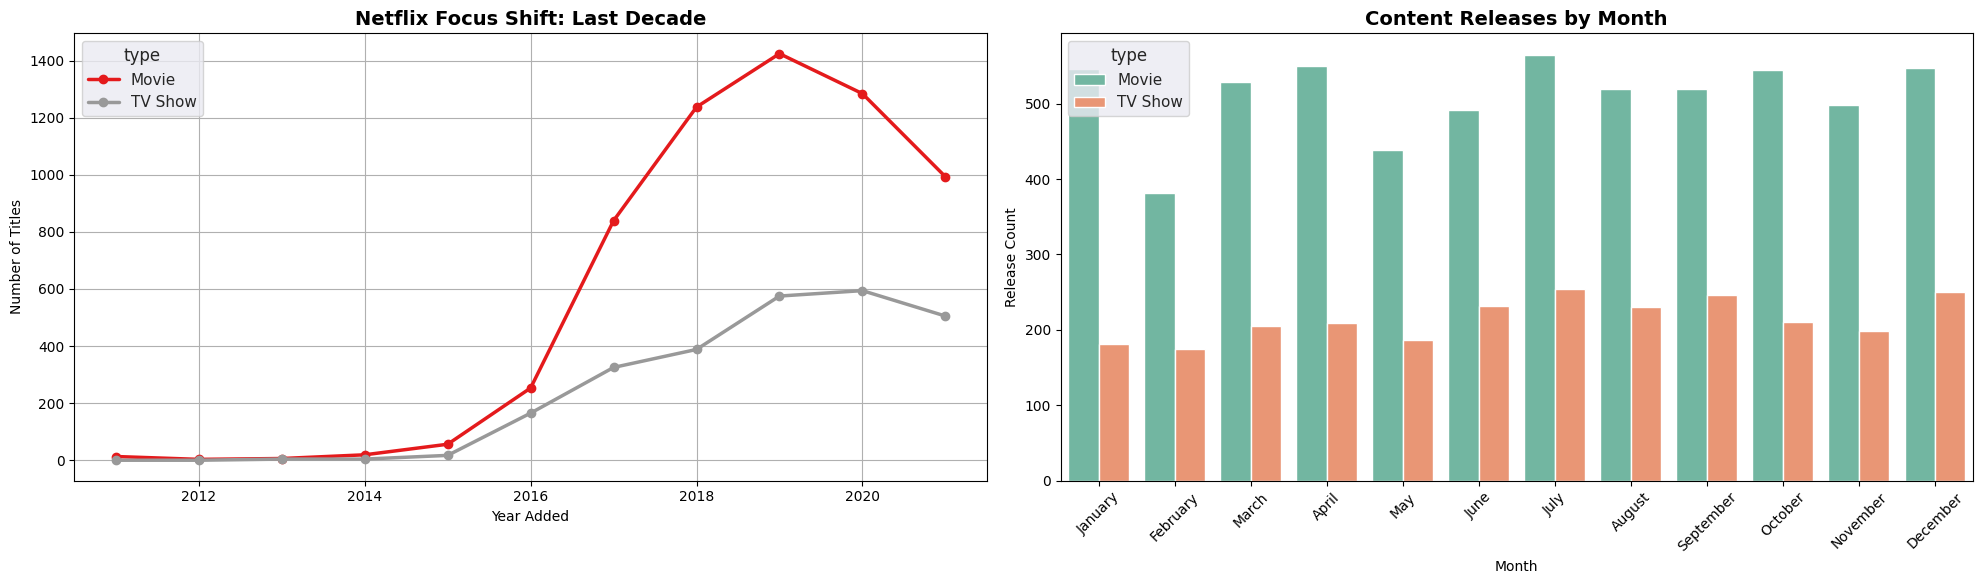

In [ ]:
# ==========================================
# PART 1: TEMPORAL TRENDS
# ==========================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Data Engineering: Datetime Parsing
# Convert 'date_added' to datetime objects and extract year/month
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month_name()

# Set up the figure for two subplots
fig, axes = plt.subplots(1, 2, figsize=(20, 6))
sns.set_theme(style="darkgrid")

# --- PLOT A: Decade Shift (Movies vs TV Shows) ---
# Filter for the last 10 years of available data
max_year = df['year_added'].max()
recent_decade = df[df['year_added'] >= (max_year - 10)]

# Group by year and type, then unstack to format for line plotting
trend_data = recent_decade.groupby(['year_added', 'type']).size().unstack().fillna(0)
trend_data.plot(kind='line', marker='o', ax=axes[0], linewidth=2.5, cmap='Set1')

axes[0].set_title("Netflix Focus Shift: Last Decade", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Year Added")
axes[0].set_ylabel("Number of Titles")

# --- PLOT B: Popular Months for Releases ---
# Define logical month order for the X-axis
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

sns.countplot(data=df, x='month_added', order=month_order, hue='type', ax=axes[1], palette='Set2')
axes[1].set_title("Content Releases by Month", fontsize=14, fontweight='bold')
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Release Count")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

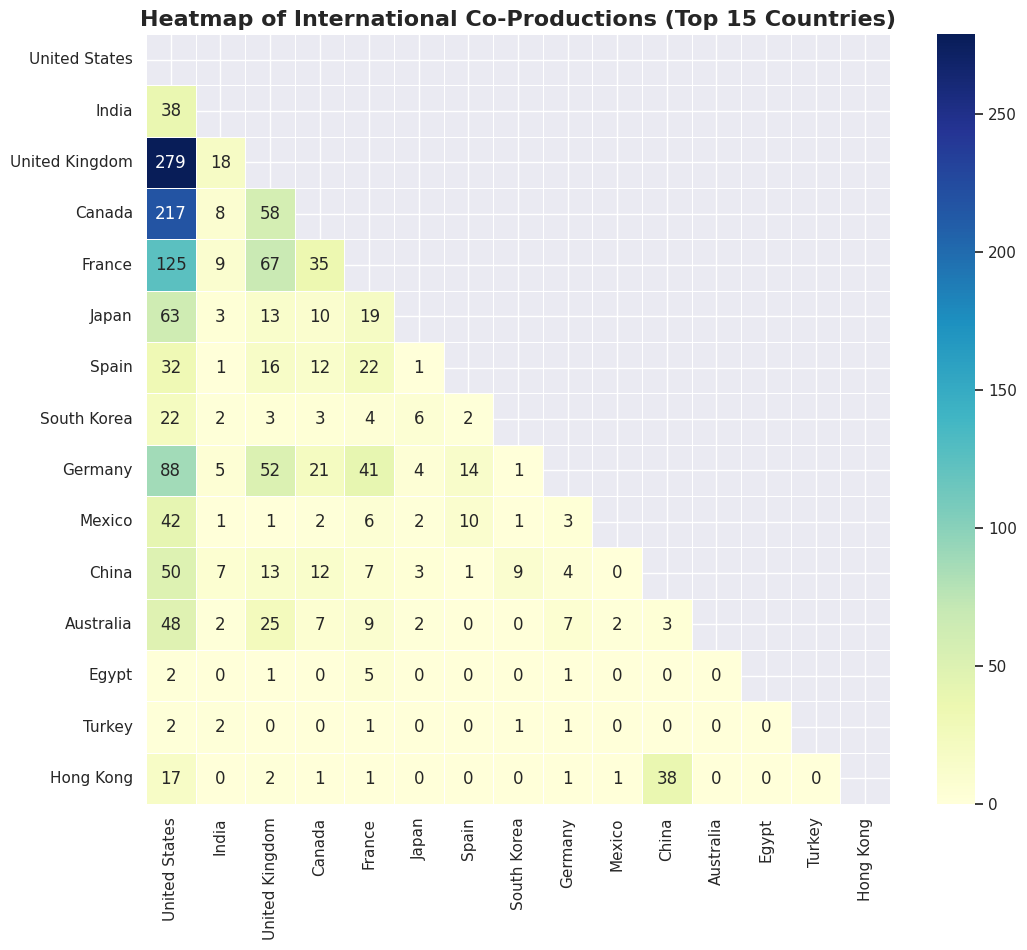

In [ ]:
# ==========================================
# PART 2: NETWORK & GEOSPATIAL ANALYSIS
# ==========================================
import itertools
from collections import Counter

# 1. Data Engineering: Unnesting Arrays
# Drop rows without country data, then split the comma-separated strings into lists
df_countries = df.dropna(subset=['country']).copy()
df_countries['country_list'] = df_countries['country'].apply(lambda x: [c.strip() for c in x.split(',')])

# Extract all individual countries to find the top 15 most frequent overall
all_countries = list(itertools.chain.from_iterable(df_countries['country_list']))
# Filter out empty strings that might occur from trailing commas
top_15_countries = [c[0] for c in Counter(all_countries).most_common(16) if c[0] != ''][:15]

# 2. Build the Co-occurrence Matrix
# Initialize an empty matrix (DataFrame) filled with zeros
matrix = pd.DataFrame(0, index=top_15_countries, columns=top_15_countries)

# Populate the matrix by checking combinations within each title's country list
for countries in df_countries['country_list']:
    # Only look at countries in our top 15
    filtered = [c for c in countries if c in top_15_countries]
    if len(filtered) > 1:
        # Generate all pairs of countries for this specific title
        for pair in itertools.combinations(filtered, 2):
            matrix.at[pair[0], pair[1]] += 1
            matrix.at[pair[1], pair[0]] += 1 # Ensure symmetry

# --- PLOT: Heatmap of Co-productions ---
plt.figure(figsize=(12, 10))
# Mask the upper triangle so we don't show duplicate mirrored data
mask = pd.DataFrame(False, index=matrix.index, columns=matrix.columns)
import numpy as np
mask = np.triu(np.ones_like(matrix, dtype=bool))

sns.heatmap(matrix, mask=mask, annot=True, fmt="d", cmap="YlGnBu", linewidths=.5)
plt.title("Heatmap of International Co-Productions (Top 15 Countries)", fontsize=16, fontweight='bold')
plt.show()

/tmp/ipykernel_6632/3314185766.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_duos, x='Count', y='Duo', ax=axes[0], palette='magma')


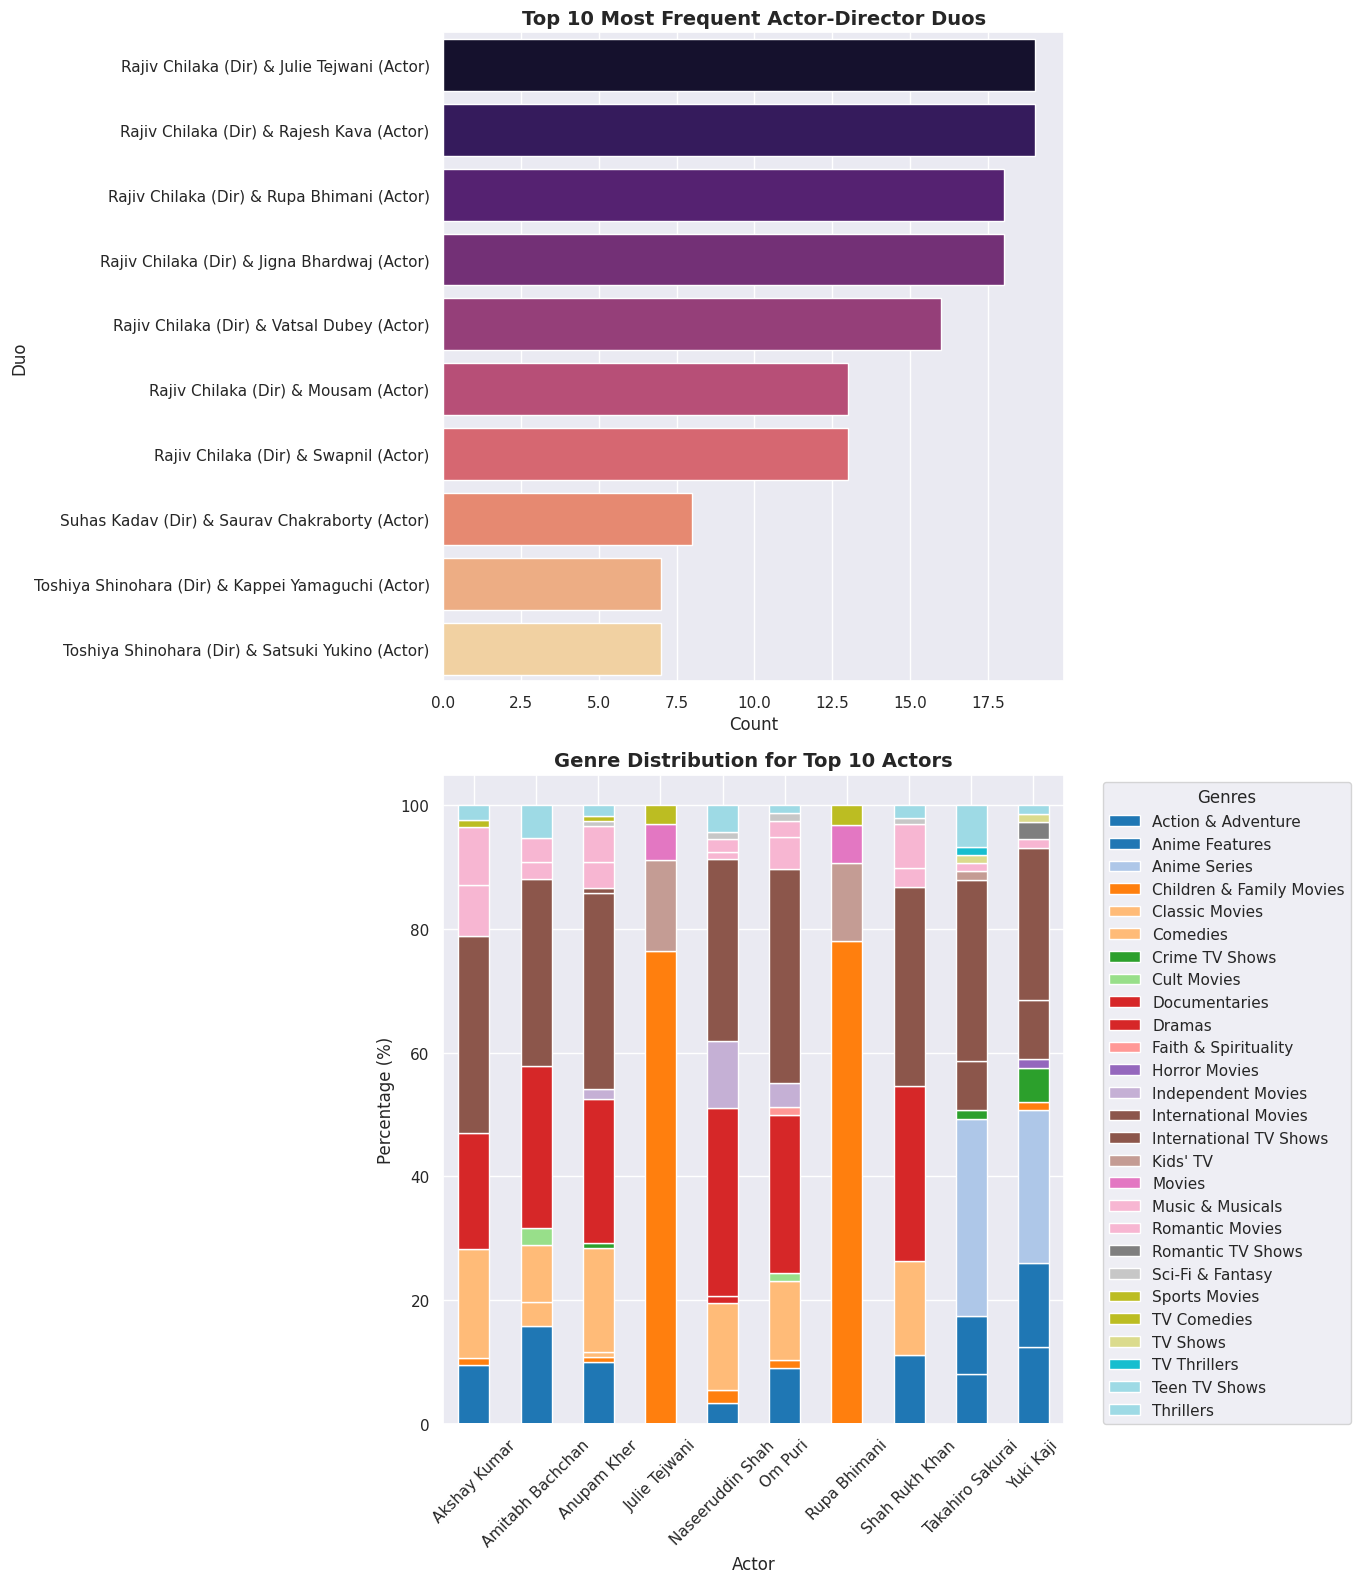

In [ ]:
# ==========================================
# PART 3: ACTOR/DIRECTOR ANALYTICS (CORRECTED)
# ==========================================

# 1. Frequent Actor-Director Duos
df_crew = df.dropna(subset=['cast', 'director']).copy()
df_crew['cast_list'] = df_crew['cast'].apply(lambda x: [c.strip() for c in x.split(',')])
df_crew['dir_list'] = df_crew['director'].apply(lambda x: [d.strip() for d in x.split(',')])

# Generate all pairings of directors and actors per title
duos = []
for _, row in df_crew.iterrows():
    for d in row['dir_list']:
        for a in row['cast_list']:
            duos.append(f"{d} (Dir) & {a} (Actor)")

top_duos = pd.DataFrame(Counter(duos).most_common(10), columns=['Duo', 'Count'])

# 2. Genre Distribution for Top 10 Actors
df_actors = df.dropna(subset=['cast', 'listed_in']).copy()

# ---> THIS IS THE LINE THAT WAS MISSING <---
df_actors['cast_list'] = df_actors['cast'].apply(lambda x: [c.strip() for c in x.split(',')])
df_actors['listed_in_list'] = df_actors['listed_in'].apply(lambda x: [g.strip() for g in x.split(',')])

# Explode the cast list so each actor gets their own row with the associated genres
df_exploded = df_actors.explode('cast_list')
df_exploded['cast_list'] = df_exploded['cast_list'].str.strip()

# Identify the top 10 actors by total appearances
top_10_actors = df_exploded['cast_list'].value_counts().head(10).index

# Filter dataset to only include these top 10 actors, then explode genres
top_actor_genres = df_exploded[df_exploded['cast_list'].isin(top_10_actors)].explode('listed_in_list')

# Create a cross-tabulation (frequency table) of actors vs genres
genre_crosstab = pd.crosstab(top_actor_genres['cast_list'], top_actor_genres['listed_in_list'])
# Normalize to get percentages for a 100% stacked bar chart
genre_pct = genre_crosstab.div(genre_crosstab.sum(1), axis=0) * 100

# --- PLOTTING ---
fig, axes = plt.subplots(2, 1, figsize=(14, 16))

# Plot A: Top Duos
sns.barplot(data=top_duos, x='Count', y='Duo', ax=axes[0], palette='magma')
axes[0].set_title("Top 10 Most Frequent Actor-Director Duos", fontsize=14, fontweight='bold')

# Plot B: 100% Stacked Bar for Actor Genres
genre_pct.plot(kind='bar', stacked=True, ax=axes[1], colormap='tab20')
axes[1].set_title("Genre Distribution for Top 10 Actors", fontsize=14, fontweight='bold')
axes[1].set_ylabel("Percentage (%)")
axes[1].set_xlabel("Actor")
axes[1].legend(title="Genres", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

/tmp/ipykernel_6632/3998406133.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_combos, x='Count', y='Combination', ax=ax_top, palette='viridis')
/tmp/ipykernel_6632/3998406133.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=horror_words, x='Count', y='Word', ax=axes[1, 0], palette='Reds_r')
/tmp/ipykernel_6632/3998406133.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=comedy_words, x='Count', y='Word', ax=axes[1, 1], palette='Blues_r')


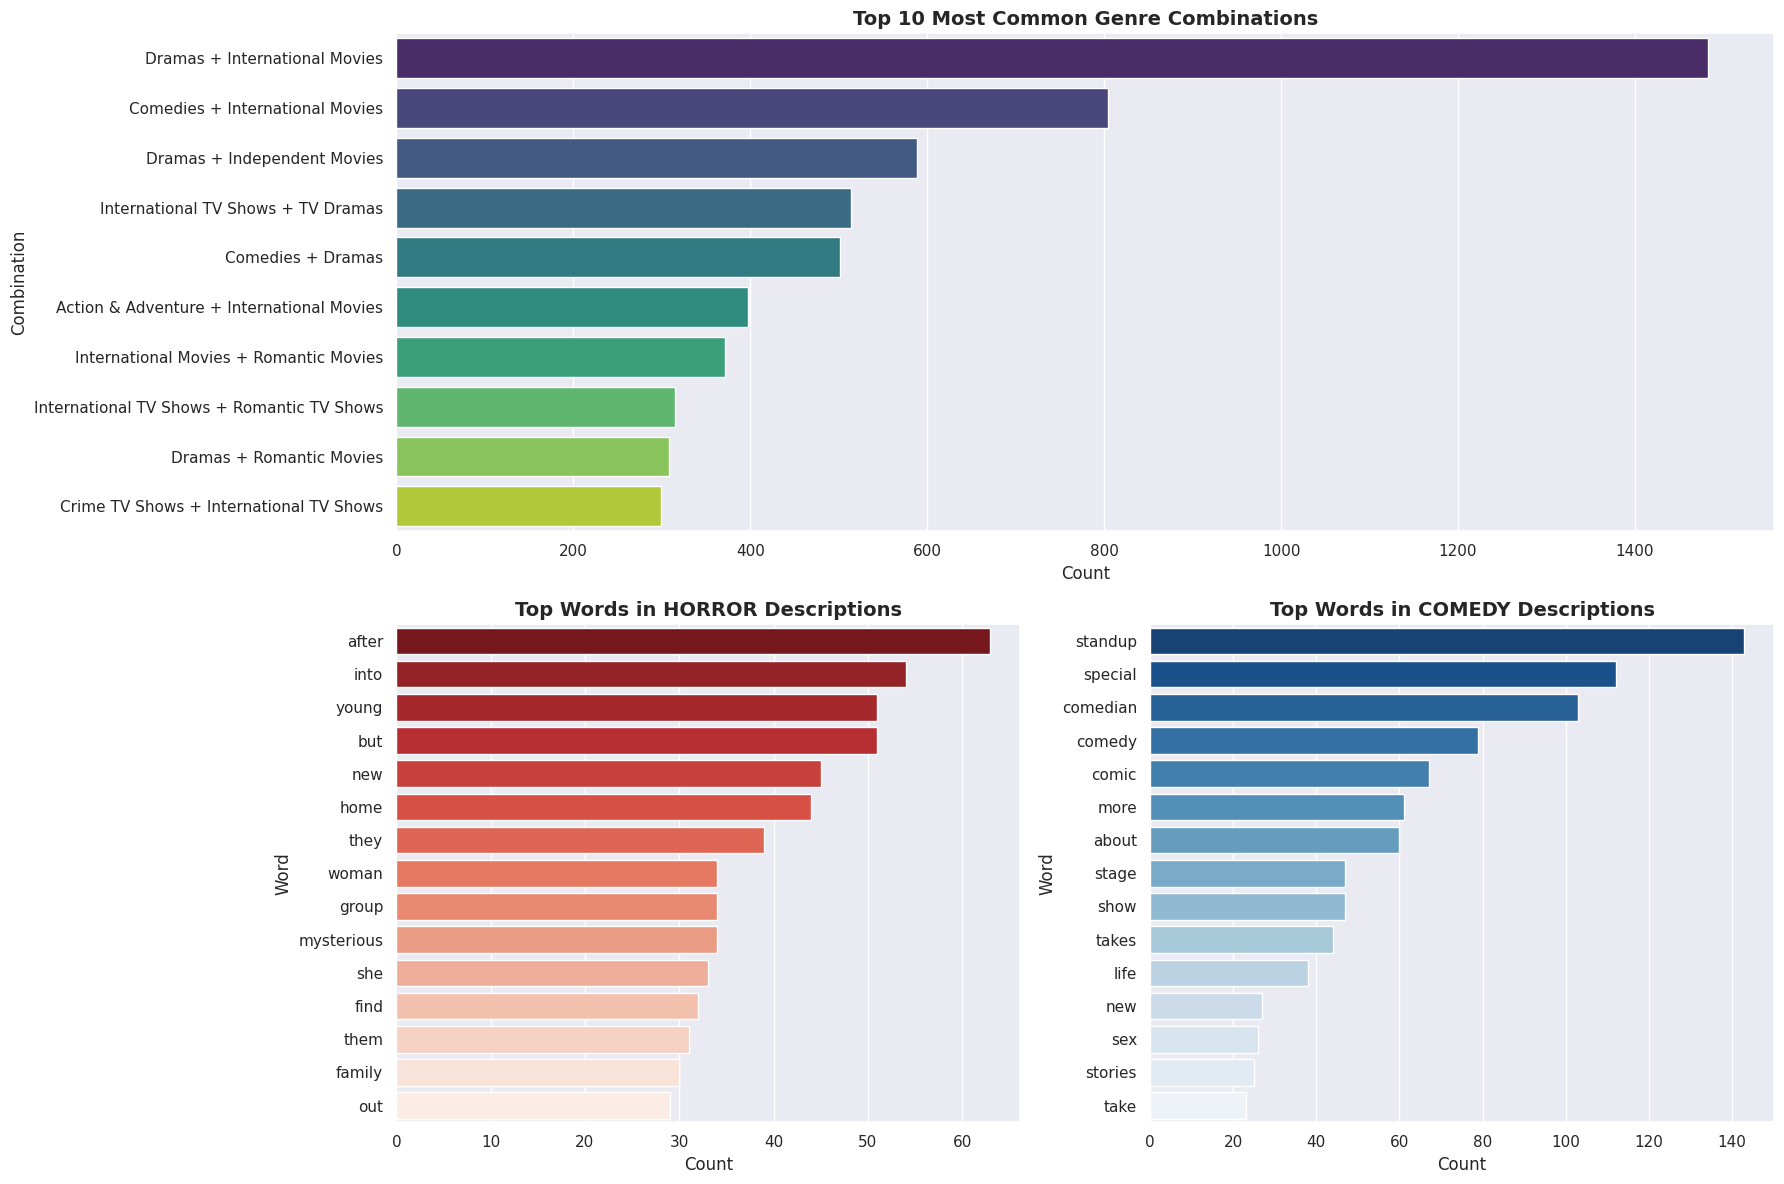

In [ ]:
# ==========================================
# PART 4: TEXT & GENRE ANALYSIS
# ==========================================
import re

# --- 1. Genre Combinations ---
df_genres = df.dropna(subset=['listed_in']).copy()
df_genres['genre_list'] = df_genres['listed_in'].apply(lambda x: [g.strip() for g in x.split(',')])

genre_combos = []
for genres in df_genres['genre_list']:
    if len(genres) > 1:
        # Sort alphabetically to ensure "Action, Comedy" matches "Comedy, Action"
        for pair in itertools.combinations(sorted(genres), 2):
            genre_combos.append(f"{pair[0]} + {pair[1]}")

top_combos = pd.DataFrame(Counter(genre_combos).most_common(10), columns=['Combination', 'Count'])

# --- 2. Text Analysis: Horror vs Comedy ---
# Basic stop words list to filter out common English words from descriptions
stop_words = set(['the', 'and', 'to', 'a', 'of', 'in', 'is', 'his', 'her', 'for', 'with',
                  'on', 'as', 'by', 'an', 'that', 'from', 'who', 'this', 'their', 'are', 'when'])

def get_top_words(genre_keyword, top_n=15):
    # Filter descriptions that contain the target genre
    text_data = df[df['listed_in'].str.contains(genre_keyword, case=False, na=False)]['description']

    words = []
    for desc in text_data:
        # Lowercase and remove punctuation using regex
        clean_desc = re.sub(r'[^\w\s]', '', str(desc).lower())
        # Split into words and filter out stopwords
        words.extend([w for w in clean_desc.split() if w not in stop_words and len(w) > 2])

    return pd.DataFrame(Counter(words).most_common(top_n), columns=['Word', 'Count'])

horror_words = get_top_words('Horror')
comedy_words = get_top_words('Comedy')

# --- PLOTTING ---
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Plot A: Genre Combinations (Spans the top row)
gs = axes[0, 0].get_gridspec()
axes[0, 0].remove()
axes[0, 1].remove()
ax_top = fig.add_subplot(gs[0, :])

sns.barplot(data=top_combos, x='Count', y='Combination', ax=ax_top, palette='viridis')
ax_top.set_title("Top 10 Most Common Genre Combinations", fontsize=14, fontweight='bold')

# Plot B & C: Horror vs Comedy Words
sns.barplot(data=horror_words, x='Count', y='Word', ax=axes[1, 0], palette='Reds_r')
axes[1, 0].set_title("Top Words in HORROR Descriptions", fontsize=14, fontweight='bold')

sns.barplot(data=comedy_words, x='Count', y='Word', ax=axes[1, 1], palette='Blues_r')
axes[1, 1].set_title("Top Words in COMEDY Descriptions", fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()